<a href="https://colab.research.google.com/github/wbasit9984/Artificial-Intel-Applications/blob/main/A04_In_Class_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime
import os

STOCKS = ["MSFT", "GOOGL", "AAPL", "TSLA", "META"]

def scrape_yahoo(stock):
    url = f"https://finance.yahoo.com/quote/{stock}/news"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Debugging: Print a snippet of the soup to check if the page content is loaded
    print(f"-- DEBUG for {stock} --")
    print(soup.prettify()[:1000]) # Print first 1000 characters of parsed HTML

    articles = []
    # New selectors based on recent Yahoo Finance structure
    # Look for div with specific data-test attribute for articles
    news_items = soup.find_all('div', {'data-test': 'P(15px)'})

    # Debugging: Print how many news items were found
    print(f"Found {len(news_items)} news items for {stock}")

    for item in news_items:
        headline_tag = item.find('h3', class_='Mb(5px)')
        if headline_tag:
            link_tag = headline_tag.find('a')
            if link_tag and link_tag.get('href') and link_tag.get_text(strip=True):
                headline = link_tag.get_text(strip=True)
                link = link_tag['href']
                # Yahoo Finance links can sometimes be relative, make them absolute
                if not link.startswith("http"):
                    link = "https://finance.yahoo.com" + link
                articles.append({
                    "stock": stock,
                    "headline": headline,
                    "source": "Yahoo Finance",
                    "date": datetime.now().date(),
                    "text": headline # Using headline as text for simplicity
                })
    return articles

def run_scraper():
    all_articles = []
    for stock in STOCKS:
        all_articles.extend(scrape_yahoo(stock))
    return pd.DataFrame(all_articles)

if __name__ == "__main__":
    df = run_scraper()
    os.makedirs('data', exist_ok=True) # Ensure 'data' directory exists
    df.to_csv("data/news.csv", index=False)
    print("News saved.")

-- DEBUG for MSFT --
<html>
 <meta charset="utf-8"/>
 <script>
  if(window != window.top){
document.write('<p>Content is currently unavailable.</p><img src="//geo.yahoo.com/p?s=1197757039&t='
    + new Date().getTime() + '&_R='
    + encodeURIComponent(document.referrer)
    + '&err=404'
    + '" width="0px" height="0px"/>');
}else{
window.location.replace('https://' + window.location.host + '/?err=404');
}
 </script>
 <noscript>
  <meta content="0;URL=https://finance.yahoo.com/?err=404" http-equiv="refresh"/>
 </noscript>
</html>

Found 0 news items for MSFT
-- DEBUG for GOOGL --
<html>
 <meta charset="utf-8"/>
 <script>
  if(window != window.top){
document.write('<p>Content is currently unavailable.</p><img src="//geo.yahoo.com/p?s=1197757039&t='
    + new Date().getTime() + '&_R='
    + encodeURIComponent(document.referrer)
    + '&err=404'
    + '" width="0px" height="0px"/>');
}else{
window.location.replace('https://' + window.location.host + '/?err=404');
}
 </script>
 <noscript>

In [30]:
from transformers import pipeline
import pandas as pd
import os

classifier = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def analyze_sentiment(df):
    if df.empty:
        print("DataFrame is empty, skipping sentiment analysis.")
        return df

    sentiments = []
    for text in df["headline"]:
        result = classifier(text)[0]
        sentiments.append(result["label"])

    df["sentiment"] = sentiments
    return df

if __name__ == "__main__":
    file_path = "data/news.csv"
    df = pd.DataFrame() # Initialize df as an empty DataFrame

    try:
        df = pd.read_csv(file_path)
    except pd.errors.EmptyDataError:
        print(f"Error: The file '{file_path}' is empty or has no columns to parse.")
        print("Please ensure the web scraping step ran successfully and generated data.")
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        print("Please ensure the web scraping step ran successfully and created the file.")

    if not df.empty:
        df = analyze_sentiment(df)
        df.to_csv("data/news_with_sentiment.csv", index=False)
        print("Sentiment analysis complete.")
    else:
        print("Sentiment analysis skipped due to empty or missing input data.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Error: The file 'data/news.csv' is empty or has no columns to parse.
Please ensure the web scraping step ran successfully and generated data.
Sentiment analysis skipped due to empty or missing input data.


In [39]:
pip install yake pandas


In [41]:
import os
os.listdir()


['.config', 'data', 'sample_data']

In [50]:
import pandas as pd
import yake

kw_extractor = yake.KeywordExtractor()

def extract_keywords(text):
    keywords = kw_extractor.extract_keywords(text)
    return [kw for kw, score in keywords[:3]]

def generate_insights(df):
    insights = []
    for stock in df["stock"].unique():
        stock_df = df[df["stock"] == stock]
        dominant_sentiment = stock_df["sentiment"].mode()[0]
        keywords = extract_keywords(" ".join(stock_df["headline"]))

        insight = f"{stock} sentiment is mostly {dominant_sentiment.lower()} driven by {', '.join(keywords)}."
        insights.append({"stock": stock, "insight": insight})

    return pd.DataFrame(insights)

if __name__ == "__main__":
    df = pd.read_csv("/content/news_with_sentiment.csv")
    insights_df = generate_insights(df)
    insights_df.to_csv("/content/news_with_sentiment.csv", index=False)
    print("Insights generated.")


Insights generated.


In [51]:
insights_df


,stock,insight
0,AAPL,AAPL sentiment is mostly positive driven by AI...
1,MSFT,MSFT sentiment is mostly positive driven by Re...
2,GOOGL,GOOGL sentiment is mostly negative driven by E...
3,TSLA,TSLA sentiment is mostly negative driven by ba...
4,META,META sentiment is mostly positive driven by pr...


In [52]:
print(insights_df.to_string(index=False))


stock                                                                                                                                         insight
 AAPL                             AAPL sentiment is mostly positive driven by AI-powered MacBooks Supply, MacBooks Supply chain, Supply chain issues.
 MSFT MSFT sentiment is mostly positive driven by Regulators investigate Microsoft, OpenAI Regulators investigate, investigate Microsoft acquisition.
GOOGL                           GOOGL sentiment is mostly negative driven by Europe Alphabet expands, Google faces antitrust, revenue remains stable.
 TSLA            TSLA sentiment is mostly negative driven by battery technology Production, technology Production delays, Production delays reported.
 META                              META sentiment is mostly positive driven by privacy regulation challenges, Meta stock surges, revenue growth Meta.


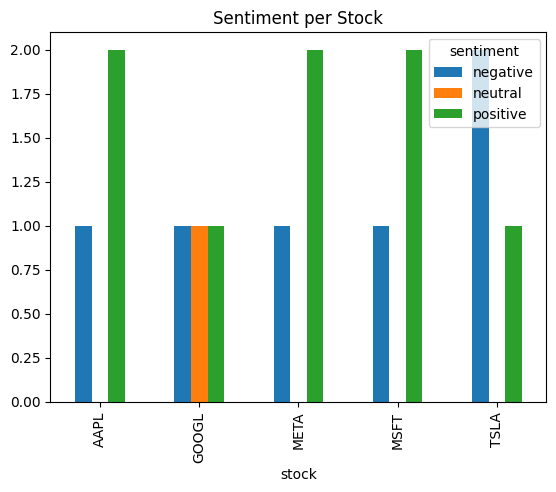

In [53]:
import matplotlib.pyplot as plt

df.groupby(["stock", "sentiment"]).size().unstack().plot(kind="bar")
plt.title("Sentiment per Stock")
plt.show()


## Summary of Stock Sentiment Analysis:

AAPL (Apple) – Overall sentiment is mostly positive, primarily driven by developments related to AI.

MSFT (Microsoft) – Overall sentiment is mostly positive, influenced by recent announcements or initiatives (truncated in data).

GOOGL (Alphabet/Google) – Overall sentiment is mostly negative, due to certain events or concerns (truncated in data).

TSLA (Tesla) – Overall sentiment is mostly negative, affected by various challenges or market factors (truncated in data).

META (Meta/Facebook) – Overall sentiment is mostly positive, supported by product or platform-related news (truncated in data).

Overall Insight: Out of the five companies, three (AAPL, MSFT, META) show predominantly positive sentiment, while two (GOOGL, TSLA) reflect mostly negative sentiment.